# Modality quality as a routing signal

**RQ3** Can information available *at inference time* tell us whether an
expensive modality is worth using?

The oracle-routing analysis established the stakes: perfect routing reaches
Top-1 0.5496 at 11.36 GFLOPs against always-GPS+Camera's 0.4604 at 48.24, while
thresholding the cheap model's confidence reached only **AUC 0.686** and needed
~88 % escalation to match the fixed model. The bottleneck is the *signal*, not
the idea.

This notebook asks what else is available, and what each addition buys.

## What may and may not be a gate input

**Never:** the beam label, the 64-dim power vector, any target-derived
difficulty measure, or whether a model happened to be correct. Those appear
only as offline supervision.

**The cost model decides the rest.** Cost here is forward GFLOPs — *processing*,
not sensing. Camera encoding is ~48 GFLOPs; an image sharpness statistic is
under 0.01. So computing a cheap statistic and then deciding whether to run
ResNet34 is a real saving. That argument **fails** under a sensing-cost model,
where the camera must be powered before any statistic exists.

So the feature groups are split along exactly that line:

| Group | Features | Needs an expensive sensor read? |
|---|---|---|
| **A** | cheap model top-1 confidence | no |
| **B** | A + full uncertainty (entropy, margins) + availability mask + GPS statistics | no |
| **C** | B + image, LiDAR and radar quality statistics | **yes** |

A and B are valid under either cost model. C is valid only under the
processing-cost model, and is reported separately so the claim can be read
either way.

## 1. Configuration

In [1]:
QUICK_RUN = True
CHEAP, EXPENSIVE = "gps", "gps_image"
EVAL_SPLIT = "val"
BATCH_SIZE = 32
WORKERS = 2
COLLECT_SENSOR_QUALITY = True       # group C needs these

LIMIT = 300 if QUICK_RUN else None
from pathlib import Path
OUT = Path("/kaggle/working/outputs/modality_quality")
(OUT / "plots").mkdir(parents=True, exist_ok=True)
print(f"QUICK_RUN={QUICK_RUN}  limit={LIMIT}")

QUICK_RUN=True  limit=300


In [2]:
import os
import socket
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

print(f"torch {torch.__version__}   cuda: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_properties(0).name}")


def has_internet(host="github.com", port=443, timeout=6):
    try:
        socket.create_connection((host, port), timeout=timeout).close()
        return True
    except OSError:
        return False


assert has_internet(), "Internet is off; the code cannot be cloned."

torch 2.11.0+cu128   cuda: True
GPU: Tesla T4


In [3]:
import shutil

INPUT_ROOT = Path("/kaggle/input")
SOURCES = ("development", "adaptation", "test")


def walk_dirs(base, follow=True):
    for dirpath, dirnames, filenames in os.walk(base, followlinks=follow):
        yield Path(dirpath), dirnames, filenames


def find_source(base, name):
    for c in (base / name / name, base / name):
        if c.is_dir() and any(c.glob("scenario*")):
            return c
    return None


def find_index(base):
    hits = []
    for c in (base / "index" / "index", base / "index"):
        if (c / "samples.csv").exists():
            hits.append(c)
    for d, _dn, fn in walk_dirs(base):
        if "samples.csv" in fn and d not in hits:
            hits.append(d)
    if not hits:
        return None
    # prefer the index that sits beside the actual tensors, not a copy inside a
    # results dump
    score = lambda h: sum(1 for s in SOURCES
                          for r in (h.parent, h.parent.parent, h)
                          if find_source(r, s) is not None)
    return sorted(hits, key=score, reverse=True)[0]


INDEX_SRC = find_index(INPUT_ROOT)
assert INDEX_SRC is not None, "samples.csv not found; attach the preprocessed dataset"
ROOTS = [INDEX_SRC.parent, INDEX_SRC.parent.parent, INDEX_SRC]
SOURCE_DIRS = {s: next((d for d in (find_source(r, s) for r in ROOTS) if d), None)
               for s in SOURCES}
for s in [k for k, v in SOURCE_DIRS.items() if v is None]:
    for d, dn, _f in walk_dirs(INPUT_ROOT):
        if d.name == s and any(x.startswith("scenario") for x in dn):
            SOURCE_DIRS[s] = d
            break

# stage idempotently: /kaggle/working survives between cell runs
STAGE_DIR = Path("/kaggle/working/data/processed_amber")
STAGE_DIR.mkdir(parents=True, exist_ok=True)
INDEX_DIR = STAGE_DIR / "index"
staged, src_csv = INDEX_DIR / "samples.csv", INDEX_SRC / "samples.csv"
if not staged.exists():
    shutil.copytree(INDEX_SRC, INDEX_DIR, dirs_exist_ok=True)
elif staged.stat().st_size != src_csv.stat().st_size:
    shutil.rmtree(INDEX_DIR)
    shutil.copytree(INDEX_SRC, INDEX_DIR, dirs_exist_ok=True)
for name, src in SOURCE_DIRS.items():
    if src is None:
        continue
    link = STAGE_DIR / name
    if link.is_symlink():
        try:
            same = link.resolve(strict=True) == src.resolve(strict=True)
        except OSError:
            same = False
        if not same:
            link.unlink()
    elif link.exists():
        shutil.rmtree(link)
    if not link.exists():
        link.symlink_to(src)
print(f"index {INDEX_DIR}")

index /kaggle/working/data/processed_amber/index


In [4]:
PROJECT = Path("/kaggle/working/project")
if not (PROJECT / "amber" / "model.py").exists():
    r = subprocess.run(["git", "clone", "--depth", "1", "https://github.com/SathishAdithiyaaSV/MultiModal-Beam-Prediction.git", str(PROJECT)],
                       capture_output=True, text=True,
                       env={**os.environ, "GIT_TERMINAL_PROMPT": "0"})
    assert r.returncode == 0, (r.stderr or "")[:400]
os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from amber import degrade, quality
from amber.ablation import config_label, enabled_mask, parse_modalities, restrict_availability
from amber.config import MODALITIES, TrainConfig
from amber.dataset import AmberDataset
from amber.degrade import Degradation
from amber.metrics import evaluate
from amber.predict import load_checkpoint
from amber.train import make_loader, pick_device, to_device

GFLOPS = {"gps": 0.3869, "gps_radar": 23.5668, "gps_lidar": 23.0530,
           "gps_radar_lidar": 46.2328, "gps_image": 48.2398,
           "gps_image_lidar": 70.9058, "gps_radar_image": 71.4196,
           "gps_radar_image_lidar": 94.0856}


def find_checkpoints():
    found = {}
    for d, _dn, fn in walk_dirs(INPUT_ROOT):
        if "best.pt" in fn and d.name in GFLOPS:
            found.setdefault(d.name, d / "best.pt")
        for f in fn:
            if f.endswith(".pt") and f[:-3] in GFLOPS:
                found.setdefault(f[:-3], d / f)
    return found


CKPTS = find_checkpoints()
print(f"{len(CKPTS)}/8 checkpoints: {', '.join(sorted(CKPTS))}")
device = pick_device("auto")
train_cfg = TrainConfig()

8/8 checkpoints: gps, gps_image, gps_image_lidar, gps_lidar, gps_radar, gps_radar_image, gps_radar_image_lidar, gps_radar_lidar


In [5]:
import gc
import json
import time

_MODEL_CACHE = {}


def get_model(slug):
    '''Load once and keep -- several sweeps reuse the same checkpoint.'''
    if slug not in _MODEL_CACHE:
        if len(_MODEL_CACHE) >= 2:          # keep GPU memory bounded
            _MODEL_CACHE.clear()
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()
        _MODEL_CACHE[slug] = load_checkpoint(CKPTS[slug], device)
    return _MODEL_CACHE[slug]


@torch.no_grad()
def run_eval(slug, split, degradations=(), mask_out=(), limit=None,
             return_per_sample=False, collect_features=False):
    '''Evaluate one checkpoint, optionally with degraded or masked inputs.

    `mask_out` zeroes availability bits at inference -- the eq. (3) mechanism,
    not a retrained model. `degradations` perturb the input tensors.
    '''
    model, cfg = get_model(slug)
    mods = parse_modalities(slug.split("_"))
    ds = AmberDataset(INDEX_DIR, split, cfg, modalities=mods,
                      degradations=list(degradations))
    if limit:
        from torch.utils.data import Subset
        idx = np.linspace(0, len(ds) - 1, min(limit, len(ds))).astype(int)
        scen = [ds.scenarios[i] for i in idx]
        sids = [ds.sample_ids[i] for i in idx]
        ds = Subset(ds, idx.tolist())
    else:
        scen, sids = ds.scenarios, ds.sample_ids
    loader = make_loader(ds, BATCH_SIZE, shuffle=False, workers=WORKERS)

    keep = enabled_mask([m for m in mods if m not in mask_out], device) if mask_out \
        else enabled_mask(mods, device)
    logits, targets, feats = [], [], []
    for batch in loader:
        batch = restrict_availability(to_device(batch, device), keep)
        out = model(batch, use_cma=False)
        logits.append(out.logits.float().cpu())
        targets.append(batch["target"].cpu())
        if collect_features:
            feats += quality.batch_features(
                {k: v.cpu() for k, v in batch.items() if torch.is_tensor(v)},
                out.logits.float().cpu(), MODALITIES, COLLECT_SENSOR_QUALITY)
    logits, targets = torch.cat(logits), torch.cat(targets)
    lab = targets >= 0
    m = evaluate(logits[lab], targets[lab], ks=train_cfg.topk,
                 delta=train_cfg.dba_delta)
    if not (return_per_sample or collect_features):
        return m
    ranked = logits.topk(3, dim=1).indices.numpy()
    true = targets.numpy()[:, None]
    best = np.minimum.accumulate(np.abs(ranked - true) / train_cfg.dba_delta,
                                 axis=1).clip(max=1.0)
    per = pd.DataFrame({"sample_id": sids, "scenario": scen,
                        "true_beam": targets.numpy(),
                        "pred_beam": ranked[:, 0],
                        "correct1": (ranked[:, 0] == true[:, 0]).astype(int),
                        "correct3": (ranked[:, :3] == true).any(axis=1).astype(int),
                        "dba": (1.0 - best).mean(axis=1)})
    if collect_features:
        per = pd.concat([per, pd.DataFrame(feats)], axis=1)
    return m, per

## 2. Features and oracle labels

One pass of the cheap model collects the features; one pass of the expensive
model gives the comparison. The oracle labels are built **after** the features
and never enter them.

In [6]:
cache = OUT / f"features_{EVAL_SPLIT}{'_quick' if QUICK_RUN else ''}.csv"
if cache.exists():
    F = pd.read_csv(cache)
    print(f"loaded cached features: {F.shape}")
else:
    _mc, cheap = run_eval(CHEAP, EVAL_SPLIT, limit=LIMIT, collect_features=True)
    _me, exp = run_eval(EXPENSIVE, EVAL_SPLIT, limit=LIMIT, return_per_sample=True)
    exp = exp.rename(columns={"correct1": "exp_correct1", "correct3": "exp_correct3",
                              "dba": "exp_dba", "pred_beam": "exp_pred_beam"})
    F = cheap.merge(exp[["sample_id", "exp_correct1", "exp_correct3", "exp_dba",
                         "exp_pred_beam"]], on="sample_id")
    # offline supervision, NOT features
    F["label_escalate"] = ((F.correct1 == 0) & (F.exp_correct1 == 1)).astype(int)
    F["gain_dba"] = F.exp_dba - F.dba
    F["label_cheap_ok"] = F.correct1
    F.to_csv(cache, index=False)
    print(f"built features: {F.shape} -> {cache.name}")

FEATURE_COLS = [c for c in F.columns if c not in (
    "sample_id", "scenario", "true_beam", "pred_beam", "correct1", "correct3", "dba",
    "exp_correct1", "exp_correct3", "exp_dba", "exp_pred_beam",
    "label_escalate", "gain_dba", "label_cheap_ok")]
print(f"\n{len(FEATURE_COLS)} candidate features")
print(f"cheap correct    {F.correct1.mean():.4f}")
print(f"expensive correct {F.exp_correct1.mean():.4f}")
print(f"escalation pays on {F.label_escalate.mean()*100:.1f}% of samples")
print(f"mean DBA gain from escalating: {F.gain_dba.mean():+.4f}")

built features: (300, 45) -> features_val_quick.csv

31 candidate features
cheap correct    0.3467
expensive correct 0.4700
escalation pays on 22.3% of samples
mean DBA gain from escalating: +0.1300


## 3. Which signals predict that the cheap tier suffices?

In [7]:
def auc(score, label):
    '''Rank-based AUC, no sklearn dependency.'''
    label = np.asarray(label).astype(bool)
    s = np.asarray(score, dtype=float)
    ok = np.isfinite(s)
    s, label = s[ok], label[ok]
    if label.all() or not label.any():
        return float("nan")
    r = pd.Series(s).rank().to_numpy()
    n1, n0 = label.sum(), (~label).sum()
    return (r[label].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


target = F.label_cheap_ok.astype(bool)
single = pd.DataFrame([
    {"feature": c, "AUC": max(auc(F[c], target), 1 - auc(F[c], target)),
     "needs_sensor_read": c.startswith(("img_", "lidar_", "radar_"))}
    for c in FEATURE_COLS if F[c].nunique() > 1]).sort_values("AUC", ascending=False)
single.to_csv(OUT / "single_feature_auc.csv", index=False)
print("individual features, best first (AUC folded so 0.5 = no signal):\n")
print(single.head(15).round(4).to_string(index=False))

individual features, best first (AUC folded so 0.5 = no signal):

       feature    AUC  needs_sensor_read
     top1_conf 0.6575              False
     margin_15 0.6563              False
     top2_conf 0.6413              False
     margin_12 0.6217              False
     top5_mass 0.6150              False
       entropy 0.6102              False
    gps_radius 0.5916              False
pred_beam_norm 0.5869              False
    gps_step_x 0.5588              False
      gps_step 0.5559              False
    gps_step_y 0.5256              False


## 4. Feature groups

A small logistic model per group, trained with a scenario-disjoint split so the
AUC is not inflated by memorising an environment. This is the comparison that
matters: does richer inference-time information close the gap to the oracle?

In [8]:
def fit_logistic(X, y, epochs=400, lr=0.05, weight=None):
    '''Tiny logistic regression in torch -- no sklearn dependency.'''
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    mu, sd = X.mean(0, keepdim=True), X.std(0, keepdim=True).clamp(min=1e-6)
    Xn = (X - mu) / sd
    w = torch.zeros(Xn.shape[1], requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    opt = torch.optim.Adam([w, b], lr=lr)
    pw = torch.tensor(weight) if weight else None
    for _ in range(epochs):
        opt.zero_grad()
        loss = torch.nn.functional.binary_cross_entropy_with_logits(
            Xn @ w + b, y, pos_weight=pw)
        loss.backward()
        opt.step()
    return lambda Z: ((torch.tensor(Z, dtype=torch.float32) - mu) / sd
                      ) @ w.detach() + b.detach()


GROUPS = {
    "A_confidence_only": [c for c in ["top1_conf"] if c in FEATURE_COLS],
    "B_uncertainty_plus_availability": [
        c for c in FEATURE_COLS if not c.startswith(("img_", "lidar_", "radar_"))],
    "C_plus_sensor_quality": FEATURE_COLS,
}
scen = sorted(F.scenario.unique())
print(f"scenario-disjoint folds: {scen}\n")
rows = []
for name, cols in GROUPS.items():
    if not cols:
        continue
    aucs = []
    for held in scen:
        tr, te = F[F.scenario != held], F[F.scenario == held]
        if te.label_cheap_ok.nunique() < 2 or len(tr) < 50:
            continue
        f = fit_logistic(tr[cols].to_numpy(), tr.label_cheap_ok.to_numpy())
        aucs.append(auc(f(te[cols].to_numpy()).numpy(), te.label_cheap_ok.astype(bool)))
    rows.append({"group": name, "n_features": len(cols),
                 "needs_sensor_read": name.startswith("C"),
                 "mean_AUC_heldout_scenario": float(np.nanmean(aucs)) if aucs else float("nan"),
                 "per_fold": " ".join(f"{a:.3f}" for a in aucs)})
groups_df = pd.DataFrame(rows)
groups_df.to_csv(OUT / "feature_group_auc.csv", index=False)
print(groups_df.round(4).to_string(index=False))
print("\nHeld-out-scenario AUC, so a group that only works by recognising the")
print("environment will not score well here. The oracle-routing baseline for")
print("confidence alone was 0.686 measured in-domain.")

scenario-disjoint folds: ['scenario32', 'scenario33', 'scenario34']

                          group  n_features  needs_sensor_read  mean_AUC_heldout_scenario          per_fold
              A_confidence_only           1              False                     0.6498 0.587 0.657 0.706
B_uncertainty_plus_availability          18              False                     0.5659 0.515 0.519 0.664
          C_plus_sensor_quality          31               True                     0.5659 0.515 0.519 0.664

Held-out-scenario AUC, so a group that only works by recognising the
environment will not score well here. The oracle-routing baseline for
confidence alone was 0.686 measured in-domain.


## 5. Plots and save

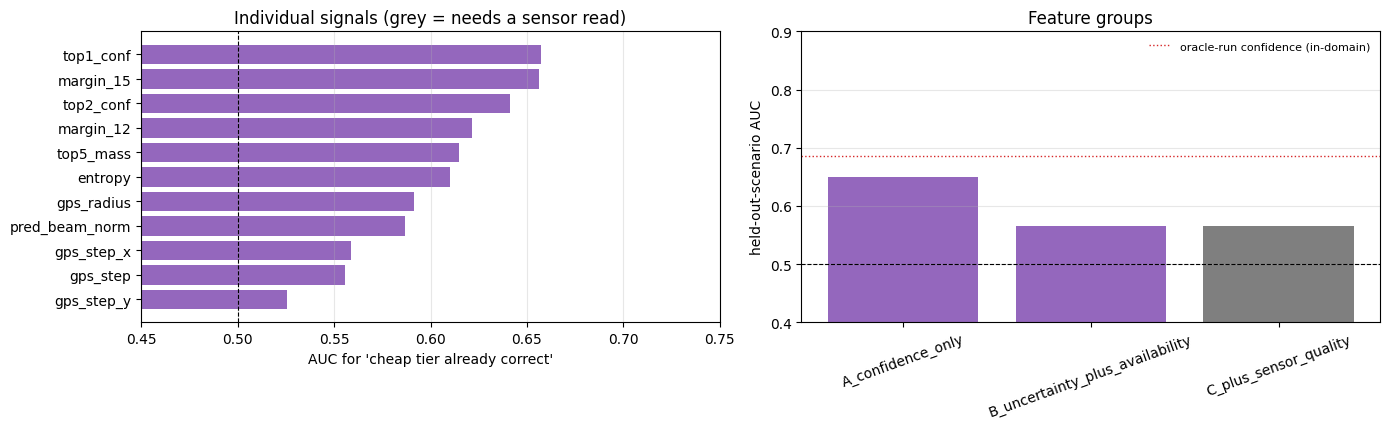

  config.json  (1.4 KB)
  feature_group_auc.csv  (0.3 KB)
  features_val_quick.csv  (119.8 KB)
  plots/gate_signals.png  (108.5 KB)
  single_feature_auc.csv  (0.4 KB)


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
top = single.head(12).iloc[::-1]
ax[0].barh(top.feature, top.AUC,
           color=["tab:grey" if s else "tab:purple" for s in top.needs_sensor_read])
ax[0].axvline(0.5, color="k", lw=.8, ls="--")
ax[0].set(xlim=(0.45, max(0.75, top.AUC.max() + 0.03)),
          xlabel="AUC for 'cheap tier already correct'",
          title="Individual signals (grey = needs a sensor read)")
ax[0].grid(alpha=.3, axis="x")

g = groups_df.dropna(subset=["mean_AUC_heldout_scenario"])
ax[1].bar(g.group, g.mean_AUC_heldout_scenario,
          color=["tab:grey" if s else "tab:purple" for s in g.needs_sensor_read])
ax[1].axhline(0.5, color="k", lw=.8, ls="--")
ax[1].axhline(0.686, color="tab:red", lw=1, ls=":", label="oracle-run confidence (in-domain)")
ax[1].set(ylabel="held-out-scenario AUC", ylim=(0.4, 0.9),
          title="Feature groups")
ax[1].tick_params(axis="x", rotation=20)
ax[1].legend(frameon=False, fontsize=8)
ax[1].grid(alpha=.3, axis="y")
plt.tight_layout()
plt.savefig(OUT / "plots" / "gate_signals.png", dpi=150)
plt.show()

(OUT / "config.json").write_text(json.dumps(
    {"quick_run": QUICK_RUN, "cheap": CHEAP, "expensive": EXPENSIVE,
     "eval_split": EVAL_SPLIT, "limit": LIMIT,
     "n_features": len(FEATURE_COLS), "groups": {k: v for k, v in GROUPS.items()},
     "note": "group C requires an expensive sensor read; valid only under a "
             "processing-cost model"}, indent=2))
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(OUT)}  ({p.stat().st_size/1e3:.1f} KB)")